In [19]:
import pandas as pd
import numpy as np
import pickle 



def load_results(path):
    with open(path, 'rb') as file:
            results = pickle.load(file)

    tools = ['Avatars K5', "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", "TVAE"]
    indexes = [0.1, 0.25, 0.5, 0.75, 1]
    df_results = pd.DataFrame(results).T
    df_results.columns = ['25%', '50%', '75%', '100%']
    df_results.index = tools

    return df_results
    

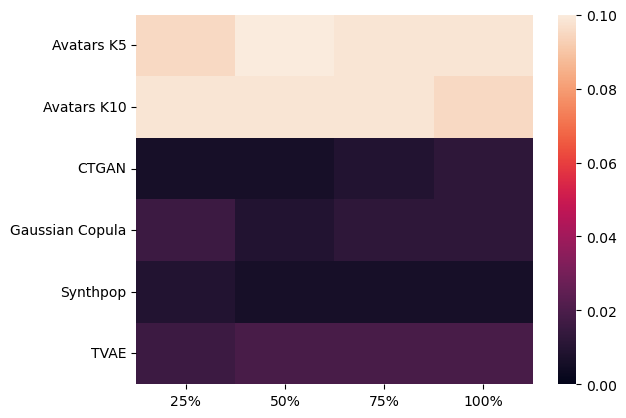

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

seed = 42
path = f'Seed_{seed}/LinkabilityResults.pkl'

df_result = load_results(path)

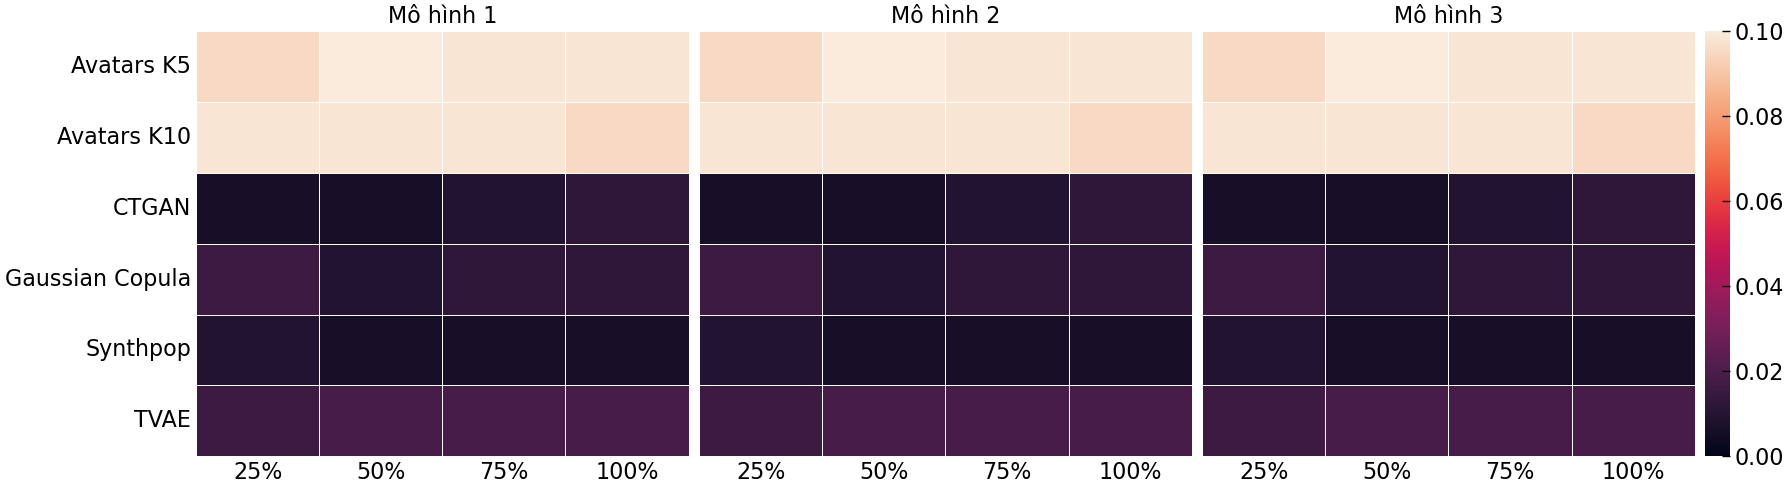

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scienceplots

plt.style.use(["science", "nature", "notebook", {"image.cmap": "inferno"}])
plt.rcParams.update({'text.usetex': False})
plt.rcParams['xtick.minor.visible'] = False
plt.rcParams['ytick.minor.visible'] = False

# Tạo layout: 1 hàng, 4 cột (3 cột cho heatmap, 1 cột rất hẹp cho colorbar)
# width_ratios giúp kiểm soát độ rộng của từng cột
fig, axes = plt.subplots(1, 4, figsize=(18, 5),
                         gridspec_kw={'width_ratios': [1, 1, 1, 0.05]})

# Lấy 3 ô đầu cho heatmap, ô cuối cho colorbar
ax1, ax2, ax3, cbar_ax = axes

vmin, vmax = 0, 0.1
line_params = {'linewidths': 0.5, 'linecolor': 'white'}
# Vẽ heatmap
sns.heatmap(df_result, ax=ax1, cbar=False, vmin=vmin, vmax=vmax, **line_params)
sns.heatmap(df_result, ax=ax2, cbar=False, vmin=vmin, vmax=vmax,yticklabels=False,**line_params)
# Vẽ heatmap thứ 3 vào ax3, nhưng chỉ định thanh màu vẽ vào cbar_ax
sns.heatmap(df_result, ax=ax3, cbar_ax=cbar_ax, vmin=vmin, vmax=vmax,yticklabels=False,**line_params)

ax1.set_title('Mô hình 1')
ax2.set_title('Mô hình 2')
ax3.set_title('Mô hình 3')

for ax in [ax1, ax2, ax3]:
    # Loại bỏ hoàn toàn các vạch chia nhỏ
    ax.tick_params(which='major', top=False, bottom=False, left=False, right=False)

plt.tight_layout()
plt.show()